# T2 - Pipeline Final: MediaPipe Landmarks + SVM

## Objetivo

Este notebook apresenta a melhor estratégia encontrada para a continuação do T1: classificar poses de yoga usando **landmarks corporais** extraídos por uma rede neural pré-treinada e um classificador SVM.

A pipeline final é:

Imagem de entrada
→ MediaPipe Pose
→ Extração de 33 landmarks corporais
→ Normalização geométrica da pose
→ Treinamento de SVM
→ Avaliação com métricas e matriz de confusão

O ponto principal é que a rede neural não classifica a imagem inteira. Ela é usada para detectar a estrutura corporal. Depois disso, o SVM classifica a pose a partir da geometria do corpo.

## 0. Dependências

Este notebook deve ser executado no ambiente MediaPipe:

```bash
pip install -r requirements-mediapipe.txt
python -m ipykernel install --user --name yoga-mediapipe --display-name "Python (yoga-mediapipe)"
```

No Jupyter, selecione o kernel **Python (yoga-mediapipe)**.

In [1]:
from pathlib import Path
import random

import cv2
import joblib
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm import tqdm

if not hasattr(mp, "solutions"):
    raise RuntimeError(
        "A versão instalada do MediaPipe não possui mp.solutions.pose. "
        "Use o ambiente correto e instale: pip install -r requirements-mediapipe.txt"
    )

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASET_DIR = Path("dataset")
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
SVM_MODEL_PATH = MODEL_DIR / "t2_landmarks_svm.joblib"
METADATA_PATH = MODEL_DIR / "t2_landmarks_metadata.joblib"

assert DATASET_DIR.exists(), f"Dataset não encontrado: {DATASET_DIR.resolve()}"
print("Dataset:", DATASET_DIR.resolve())
print("MediaPipe:", getattr(mp, "__version__", "sem versão"))

Dataset: /Users/marcos/Desktop/Projetos/T1VisaoComputacional/dataset
MediaPipe: 0.10.21


## 1. Leitura do dataset

As imagens estão organizadas por pastas, em que cada pasta representa uma classe. Pastas vazias são ignoradas.

In [2]:
def montar_dataframe_dataset(dataset_dir: Path, img_exts: set[str]) -> pd.DataFrame:
    linhas = []

    for classe_dir in sorted(p for p in dataset_dir.iterdir() if p.is_dir()):
        imagens = sorted(
            p for p in classe_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in img_exts
        )

        if len(imagens) == 0:
            continue

        for caminho in imagens:
            linhas.append({"path": str(caminho), "label": classe_dir.name})

    df = pd.DataFrame(linhas)
    assert len(df) > 0, "Nenhuma imagem válida encontrada."
    return df


df = montar_dataframe_dataset(DATASET_DIR, IMG_EXTS)
classes = sorted(df["label"].unique())
class_to_id = {classe: idx for idx, classe in enumerate(classes)}
id_to_class = {idx: classe for classe, idx in class_to_id.items()}
df["label_id"] = df["label"].map(class_to_id).astype("int32")

print("Total de imagens:", len(df))
print("Total de classes:", len(classes))
display(df.head())

Total de imagens: 2756
Total de classes: 47


,path,label,label_id
0,dataset/afundo_alto/File1.jpeg,afundo_alto,0
1,dataset/afundo_alto/File10.jpeg,afundo_alto,0
2,dataset/afundo_alto/File11.png,afundo_alto,0
3,dataset/afundo_alto/File12.jpeg,afundo_alto,0
4,dataset/afundo_alto/File13.png,afundo_alto,0


,label,qtd_imagens
0,postura_do_camelo,96
1,meia_torcao_espinhal,96
2,postura_da_vaca,94
3,postura_da_aguia,85
4,postura_do_grou,84
5,postura_do_angulo_ligado,81
6,postura_da_cadeira,81
7,postura_da_prancha_lateral,80
8,postura_da_crianca,79
9,postura_do_lotus,77


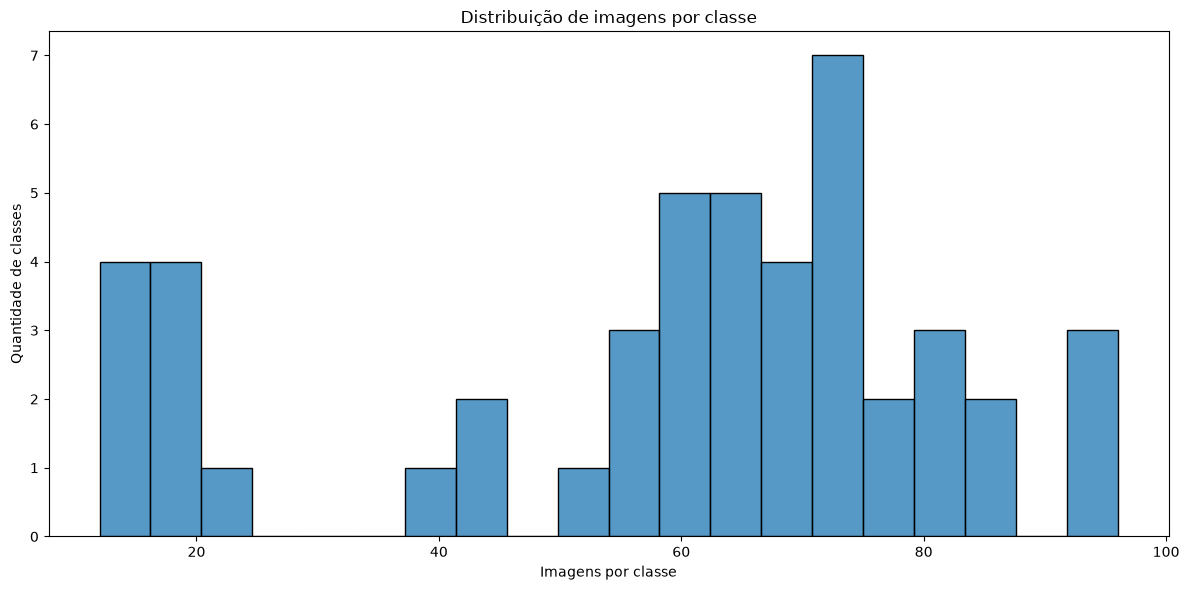

In [3]:
df_classes = (
    df.groupby("label")
      .size()
      .reset_index(name="qtd_imagens")
      .sort_values("qtd_imagens", ascending=False)
      .reset_index(drop=True)
)

display(df_classes)

plt.figure(figsize=(12, 6))
sns.histplot(df_classes["qtd_imagens"], bins=20)
plt.title("Distribuição de imagens por classe")
plt.xlabel("Imagens por classe")
plt.ylabel("Quantidade de classes")
plt.tight_layout()
plt.show()

## 2. Separação em treino, validação e teste

Usamos validação para escolher o melhor valor de `C` do SVM e teste para a avaliação final.

In [4]:
df_train, df_temp = train_test_split(
    df,
    test_size=VALIDATION_SIZE + TEST_SIZE,
    random_state=SEED,
    stratify=df["label_id"],
)

relative_test_size = TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE)

df_val, df_test = train_test_split(
    df_temp,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=df_temp["label_id"],
)

print("Treino:", df_train.shape)
print("Validação:", df_val.shape)
print("Teste:", df_test.shape)

pd.DataFrame({
    "split": ["treino", "validacao", "teste"],
    "imagens": [len(df_train), len(df_val), len(df_test)],
    "percentual": [len(df_train) / len(df), len(df_val) / len(df), len(df_test) / len(df)],
})

Treino: (1929, 3)
Validação: (413, 3)
Teste: (414, 3)


,split,imagens,percentual
0,treino,1929,0.699927
1,validacao,413,0.149855
2,teste,414,0.150218


## 3. Extração dos landmarks

O MediaPipe Pose retorna 33 pontos corporais. Cada ponto possui `x`, `y`, `z` e `visibility`.

Antes de treinar o SVM, normalizamos os pontos:

- centralizamos a pose no quadril;
- dividimos pelo tamanho do torso/ombros/quadril;
- reduzimos o efeito de escala e posição da pessoa na imagem.

In [5]:
POSE_LANDMARKS = 33
LANDMARK_DIMS = 4
LANDMARK_FEATURES = POSE_LANDMARKS * LANDMARK_DIMS

LEFT_SHOULDER = 11
RIGHT_SHOULDER = 12
LEFT_HIP = 23
RIGHT_HIP = 24


def normalizar_landmarks(landmarks: np.ndarray) -> np.ndarray:
    pontos = landmarks.astype("float32").copy()

    quadril = (pontos[LEFT_HIP, :2] + pontos[RIGHT_HIP, :2]) / 2.0
    ombros = (pontos[LEFT_SHOULDER, :2] + pontos[RIGHT_SHOULDER, :2]) / 2.0

    largura_ombros = np.linalg.norm(pontos[LEFT_SHOULDER, :2] - pontos[RIGHT_SHOULDER, :2])
    largura_quadril = np.linalg.norm(pontos[LEFT_HIP, :2] - pontos[RIGHT_HIP, :2])
    tamanho_torso = np.linalg.norm(ombros - quadril)
    escala = max(largura_ombros, largura_quadril, tamanho_torso, 1e-6)

    pontos[:, 0] = (pontos[:, 0] - quadril[0]) / escala
    pontos[:, 1] = (pontos[:, 1] - quadril[1]) / escala
    pontos[:, 2] = pontos[:, 2] / escala

    return pontos.reshape(-1).astype("float32")


def extrair_landmarks_imagem(caminho: str, pose):
    imagem_bgr = cv2.imread(caminho)

    if imagem_bgr is None:
        return None

    imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)
    resultado = pose.process(imagem_rgb)

    if not resultado.pose_landmarks:
        return None

    landmarks = np.array(
        [[lm.x, lm.y, lm.z, lm.visibility] for lm in resultado.pose_landmarks.landmark],
        dtype="float32",
    )

    if landmarks.shape != (POSE_LANDMARKS, LANDMARK_DIMS):
        return None

    return normalizar_landmarks(landmarks)

In [6]:
def extrair_landmarks_df(df_split: pd.DataFrame, nome_split: str):
    X = []
    y = []
    linhas = []
    falhas = []

    mp_pose = mp.solutions.pose

    with mp_pose.Pose(
        static_image_mode=True,
        model_complexity=2,
        enable_segmentation=False,
        min_detection_confidence=0.30,
    ) as pose:
        for _, linha in tqdm(df_split.iterrows(), total=len(df_split), desc=f"Landmarks {nome_split}"):
            features = extrair_landmarks_imagem(linha["path"], pose)

            if features is None:
                falhas.append(linha["path"])
                continue

            X.append(features)
            y.append(int(linha["label_id"]))
            linhas.append(linha)

    X = np.vstack(X).astype("float32") if len(X) else np.empty((0, LANDMARK_FEATURES), dtype="float32")
    y = np.array(y, dtype="int32")
    df_ok = pd.DataFrame(linhas).reset_index(drop=True)

    print(f"{nome_split}: {len(df_ok)} imagens com pose detectada / {len(df_split)}")
    print(f"{nome_split}: {len(falhas)} imagens sem pose detectada")

    return X, y, df_ok, falhas


X_train, y_train, df_train_ok, falhas_train = extrair_landmarks_df(df_train, "treino")
X_val, y_val, df_val_ok, falhas_val = extrair_landmarks_df(df_val, "validação")
X_test, y_test, df_test_ok, falhas_test = extrair_landmarks_df(df_test, "teste")

print("Shape treino:", X_train.shape)
print("Shape validação:", X_val.shape)
print("Shape teste:", X_test.shape)

I0000 00:00:1781463341.750993 3883714 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
Landmarks treino:   0%|          | 0/1929 [00:00<?, ?it/s]INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781463341.806703 3883890 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781463341.841684 3883890 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781463341.893363 3883888 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
Landmarks treino: 100%|██████████| 1929/1929 [02:04<00:00, 15.51it/s]
I0000 00:00:1781463466.125723 3883714 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4


treino: 1845 imagens com pose detectada / 1929
treino: 84 imagens sem pose detectada


Landmarks validação:   0%|          | 0/413 [00:00<?, ?it/s]W0000 00:00:1781463466.174422 3891500 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781463466.193109 3891499 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Landmarks validação: 100%|██████████| 413/413 [00:26<00:00, 15.43it/s]
I0000 00:00:1781463492.900470 3883714 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4


validação: 396 imagens com pose detectada / 413
validação: 17 imagens sem pose detectada


Landmarks teste:   0%|          | 0/414 [00:00<?, ?it/s]W0000 00:00:1781463492.946285 3893075 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781463492.961945 3893082 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Landmarks teste: 100%|██████████| 414/414 [00:26<00:00, 15.60it/s]

teste: 396 imagens com pose detectada / 414
teste: 18 imagens sem pose detectada
Shape treino: (1845, 132)
Shape validação: (396, 132)
Shape teste: (396, 132)


In [7]:
taxa_deteccao = pd.DataFrame([
    {"split": "treino", "com_pose": len(df_train_ok), "total": len(df_train)},
    {"split": "validacao", "com_pose": len(df_val_ok), "total": len(df_val)},
    {"split": "teste", "com_pose": len(df_test_ok), "total": len(df_test)},
])

taxa_deteccao["taxa_deteccao"] = taxa_deteccao["com_pose"] / taxa_deteccao["total"]
display(taxa_deteccao)

assert len(X_train) > 0, "Nenhum landmark foi extraído no treino."
assert len(X_val) > 0, "Nenhum landmark foi extraído na validação."
assert len(X_test) > 0, "Nenhum landmark foi extraído no teste."

,split,com_pose,total,taxa_deteccao
0,treino,1845,1929,0.956454
1,validacao,396,413,0.958838
2,teste,396,414,0.956522


## 4. Treinamento do SVM

Treinamos um SVM com kernel RBF. O `StandardScaler` padroniza os landmarks antes da classificação.

O melhor valor de `C` é escolhido no conjunto de validação.

In [8]:
resultados_validacao = []
melhor_modelo = None
melhor_acc_val = -1
melhor_C = None

for C in [0.1, 1, 3, 10, 30, 100]:
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C, gamma="scale", class_weight="balanced", probability=True)),
    ])

    modelo.fit(X_train, y_train)
    pred_val = modelo.predict(X_val)
    acc_val = accuracy_score(y_val, pred_val)

    resultados_validacao.append({"C": C, "acuracia_validacao": acc_val})

    if acc_val > melhor_acc_val:
        melhor_acc_val = acc_val
        melhor_C = C
        melhor_modelo = modelo


df_validacao = pd.DataFrame(resultados_validacao)
display(df_validacao)

print("Melhor C:", melhor_C)
print(f"Melhor acurácia na validação: {melhor_acc_val:.4f}")

/Users/marcos/Desktop/Projetos/T1VisaoComputacional/.venv-mediapipe/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/marcos/Desktop/Projetos/T1VisaoComputacional/.venv-mediapipe/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/marcos/Desktop/Projetos/T1VisaoComputacional/.venv-mediapipe/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/marcos

,C,acuracia_validacao
0,0.1,0.383838
1,1.0,0.775253
2,3.0,0.830808
3,10.0,0.830808
4,30.0,0.825758
5,100.0,0.808081


Melhor C: 3
Melhor acurácia na validação: 0.8308


## 5. Avaliação final

O teste é usado apenas no final, depois da escolha do melhor `C`.

In [9]:
y_pred = melhor_modelo.predict(X_test)
y_prob = melhor_modelo.predict_proba(X_test).max(axis=1)

acc_landmarks_svm = accuracy_score(y_test, y_pred)

print(f"Acurácia no teste com MediaPipe landmarks + SVM: {acc_landmarks_svm:.4f}")
print(f"Acurácia percentual: {acc_landmarks_svm * 100:.2f}%")
print(classification_report(
    y_test,
    y_pred,
    labels=np.arange(len(classes)),
    target_names=classes,
    zero_division=0,
))

Acurácia no teste com MediaPipe landmarks + SVM: 0.8561
Acurácia percentual: 85.61%
                                        precision    recall  f1-score   support

                           afundo_alto       0.00      0.00      0.00         1
           alongamento_lateral_intenso       0.60      0.50      0.55         6
                 angulo_aberto_sentado       1.00      1.00      1.00         2
                               cadaver       1.00      1.00      1.00         3
                              espatada       1.00      1.00      1.00         6
                          flexao_em_pe       0.75      0.82      0.78        11
               flexao_sentada_a_frente       0.88      0.88      0.88         8
                              golfinho       0.56      0.62      0.59         8
                        guerreiro_dois       1.00      1.00      1.00         9
                     guerreiro_lateral       0.50      1.00      0.67         2
                        guerreiro_t

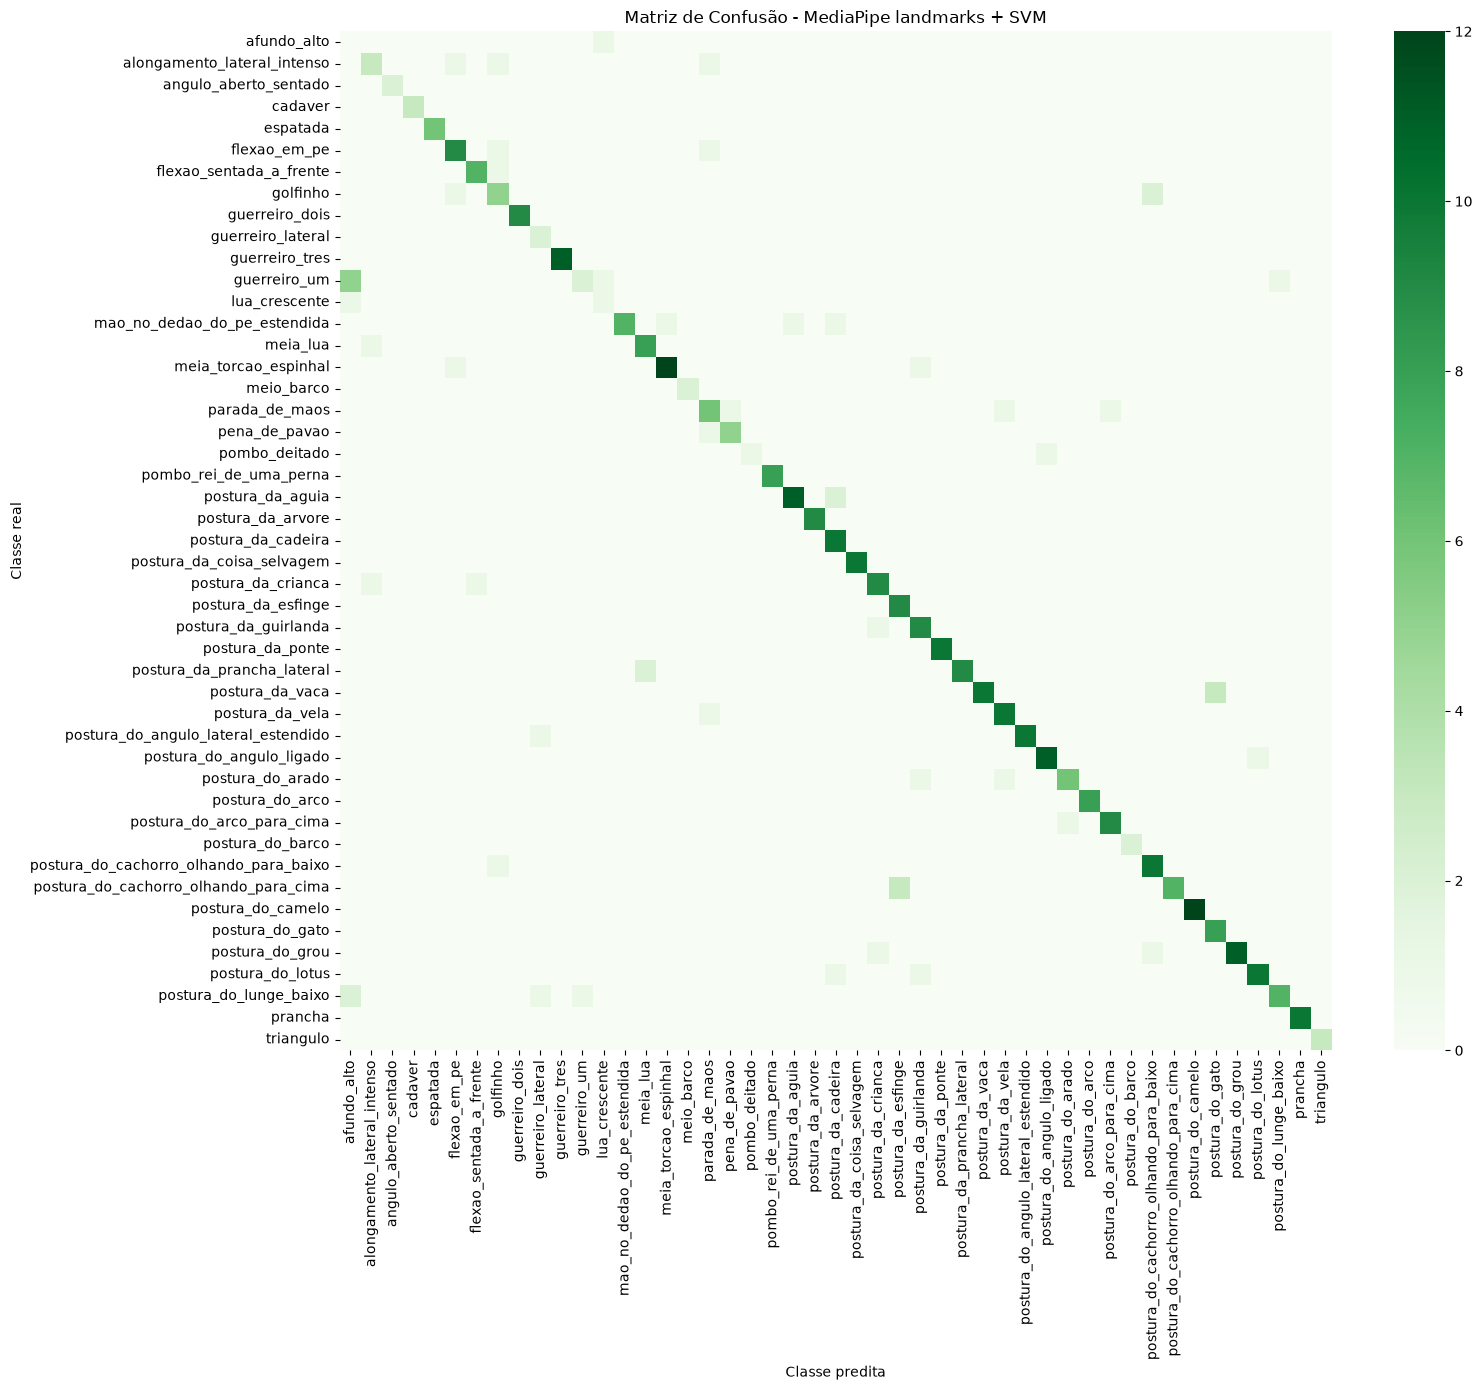

In [10]:
matriz = confusion_matrix(y_test, y_pred, labels=np.arange(len(classes)))

plt.figure(figsize=(16, 14))
sns.heatmap(
    matriz,
    cmap="Greens",
    xticklabels=classes,
    yticklabels=classes,
    cbar=True,
)
plt.title("Matriz de Confusão - MediaPipe landmarks + SVM")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Análise dos erros

Esta tabela ajuda a explicar quais poses ainda são confundidas.

In [11]:
df_resultados = df_test_ok.copy().reset_index(drop=True)
df_resultados["real_id"] = y_test
df_resultados["pred_id"] = y_pred
df_resultados["real"] = [id_to_class[int(i)] for i in y_test]
df_resultados["predito"] = [id_to_class[int(i)] for i in y_pred]
df_resultados["confianca"] = y_prob

df_erros = df_resultados[df_resultados["real_id"] != df_resultados["pred_id"]]

print("Total de amostras de teste com pose detectada:", len(df_resultados))
print("Total de erros:", len(df_erros))
print(f"Taxa de erro: {len(df_erros) / len(df_resultados):.4f}")

display(df_resultados.head())

Total de amostras de teste com pose detectada: 396
Total de erros: 57
Taxa de erro: 0.1439


,path,label,label_id,real_id,pred_id,real,predito,confianca
0,dataset/postura_da_coisa_selvagem/File41.png,postura_da_coisa_selvagem,24,24,24,postura_da_coisa_selvagem,postura_da_coisa_selvagem,0.825200
1,dataset/meia_torcao_espinhal/File27.png,meia_torcao_espinhal,15,15,15,meia_torcao_espinhal,meia_torcao_espinhal,0.438859
2,dataset/postura_do_arco/File13.png,postura_do_arco,35,35,35,postura_do_arco,postura_do_arco,0.733159
3,dataset/flexao_em_pe/File14.png,flexao_em_pe,5,5,5,flexao_em_pe,flexao_em_pe,0.596734
4,dataset/guerreiro_dois/File42.png,guerreiro_dois,8,8,8,guerreiro_dois,guerreiro_dois,0.721027


In [12]:
pares_confundidos = (
    df_erros.groupby(["real", "predito"])
    .size()
    .reset_index(name="qtd")
    .sort_values("qtd", ascending=False)
    .head(15)
)

display(pares_confundidos)

,real,predito,qtd
9,guerreiro_um,afundo_alto,5
29,postura_da_vaca,postura_do_gato,3
37,postura_do_cachorro_olhando_para_cima,postura_da_esfinge,3
42,postura_do_lunge_baixo,afundo_alto,2
28,postura_da_prancha_lateral,meia_lua,2
8,golfinho,postura_do_cachorro_olhando_para_baixo,2
24,postura_da_aguia,postura_da_cadeira,2
0,afundo_alto,lua_crescente,1
33,postura_do_arado,postura_da_guirlanda,1
26,postura_da_crianca,flexao_sentada_a_frente,1


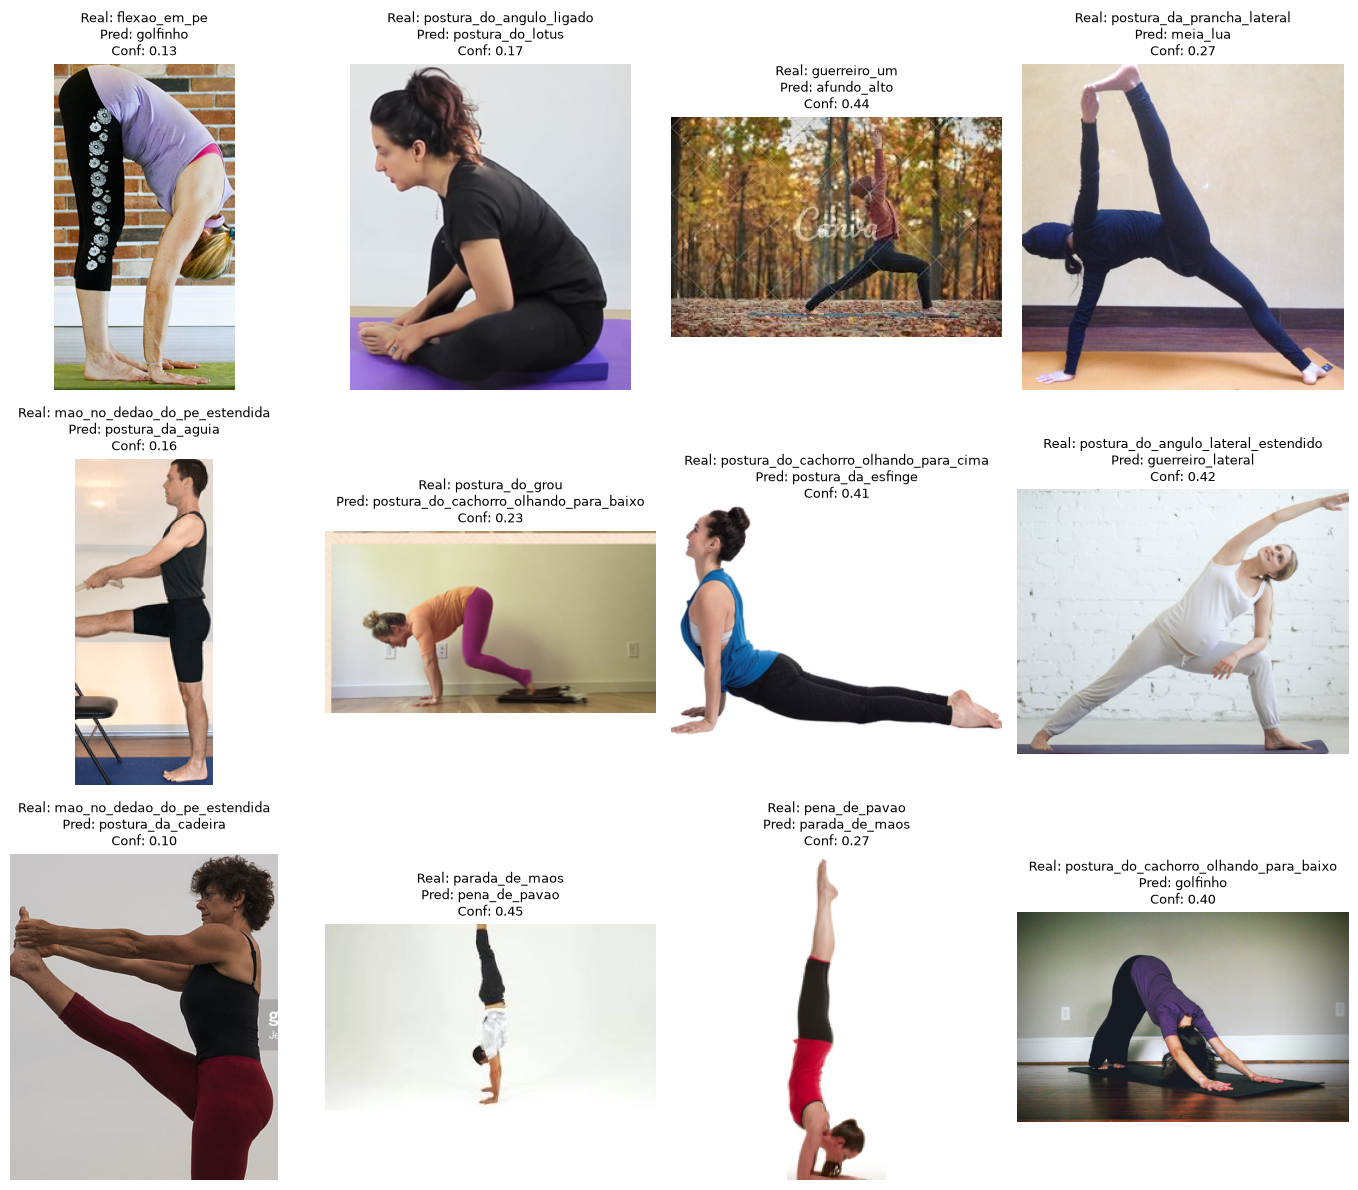

In [13]:
def mostrar_erros(df_erros: pd.DataFrame, n: int = 12):
    if len(df_erros) == 0:
        print("Nenhum erro encontrado.")
        return

    amostras = df_erros.sample(n=min(n, len(df_erros)), random_state=SEED).reset_index(drop=True)
    n_colunas = 4
    n_linhas = int(np.ceil(len(amostras) / n_colunas))

    plt.figure(figsize=(14, 4 * n_linhas))

    for i, linha in amostras.iterrows():
        imagem = cv2.imread(linha["path"])
        imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

        plt.subplot(n_linhas, n_colunas, i + 1)
        plt.imshow(imagem_rgb)
        plt.title(
            f"Real: {linha['real']}\nPred: {linha['predito']}\nConf: {linha['confianca']:.2f}",
            fontsize=9,
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


mostrar_erros(df_erros)

## 7. Comparação com o T1

Resultados de referência do T1:

- Pixels crus + SVM: **47,46%**
- HOG + SVM: **69,57%**

O resultado deste notebook mostra o ganho ao trocar a representação da imagem por landmarks corporais.

,experimento,acuracia,acuracia_percentual
0,Pixels crus + SVM (T1),0.474600,47.460000
1,HOG + SVM (T1),0.695700,69.570000
2,MediaPipe landmarks + SVM (T2),0.856061,85.606061


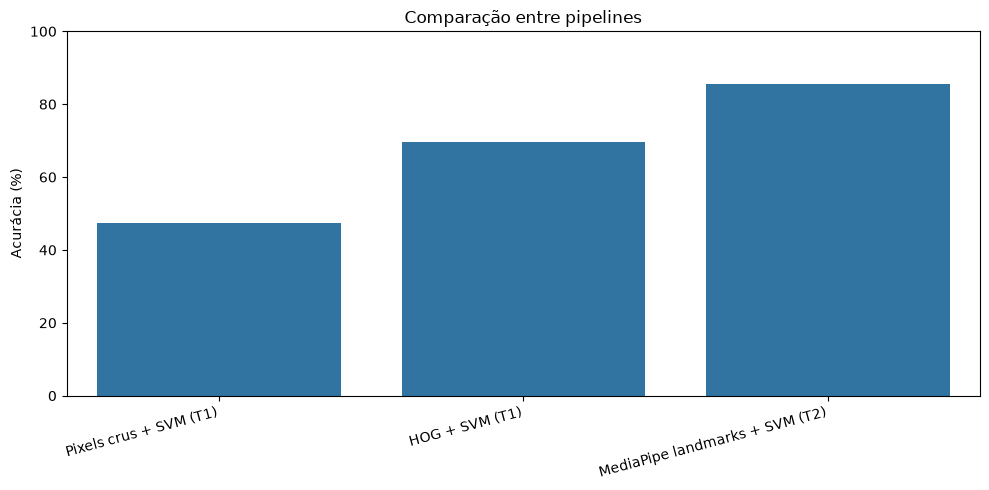

In [14]:
df_comparacao = pd.DataFrame([
    {"experimento": "Pixels crus + SVM (T1)", "acuracia": 0.4746},
    {"experimento": "HOG + SVM (T1)", "acuracia": 0.6957},
    {"experimento": "MediaPipe landmarks + SVM (T2)", "acuracia": acc_landmarks_svm},
])

df_comparacao["acuracia_percentual"] = df_comparacao["acuracia"] * 100
display(df_comparacao)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_comparacao, x="experimento", y="acuracia_percentual")
plt.title("Comparação entre pipelines")
plt.ylabel("Acurácia (%)")
plt.xlabel("")
plt.ylim(0, 100)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 8. Salvando o modelo

O modelo final e os metadados das classes são salvos para permitir demo posterior.

In [15]:
joblib.dump(melhor_modelo, SVM_MODEL_PATH)
joblib.dump(
    {
        "classes": classes,
        "class_to_id": class_to_id,
        "id_to_class": id_to_class,
        "melhor_C": melhor_C,
        "acc_teste": acc_landmarks_svm,
        "landmark_features": LANDMARK_FEATURES,
    },
    METADATA_PATH,
)

print("Modelo salvo em:", SVM_MODEL_PATH)
print("Metadados salvos em:", METADATA_PATH)

Modelo salvo em: models/t2_landmarks_svm.joblib
Metadados salvos em: models/t2_landmarks_metadata.joblib


## 9. Demo com uma imagem

A função abaixo recebe uma imagem, extrai landmarks e mostra as classes mais prováveis.

Imagem: dataset/postura_do_cachorro_olhando_para_cima/File64.jpeg
Classe real: postura_do_cachorro_olhando_para_cima


I0000 00:00:1781463524.992803 3883714 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1781463525.071629 3895016 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781463525.086933 3895017 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


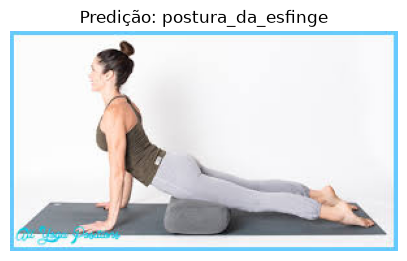

,classe,probabilidade
0,postura_da_esfinge,0.401910
1,postura_do_cachorro_olhando_para_cima,0.296778
2,postura_da_vaca,0.084184
3,postura_do_lunge_baixo,0.039908
4,prancha,0.015753


,classe,probabilidade
0,postura_da_esfinge,0.401910
1,postura_do_cachorro_olhando_para_cima,0.296778
2,postura_da_vaca,0.084184
3,postura_do_lunge_baixo,0.039908
4,prancha,0.015753


In [16]:
def prever_imagem(caminho: str, top_k: int = 5):
    mp_pose = mp.solutions.pose

    with mp_pose.Pose(
        static_image_mode=True,
        model_complexity=2,
        enable_segmentation=False,
        min_detection_confidence=0.30,
    ) as pose:
        features = extrair_landmarks_imagem(caminho, pose)

    if features is None:
        print("Não foi possível detectar pose na imagem.")
        return None

    probs = melhor_modelo.predict_proba(features.reshape(1, -1))[0]
    indices = np.argsort(probs)[::-1][:top_k]

    resultado = pd.DataFrame({
        "classe": [id_to_class[int(i)] for i in indices],
        "probabilidade": [float(probs[i]) for i in indices],
    })

    imagem = cv2.imread(caminho)
    imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5, 5))
    plt.imshow(imagem_rgb)
    plt.title(f"Predição: {resultado.iloc[0]['classe']}")
    plt.axis("off")
    plt.show()

    display(resultado)
    return resultado


amostra_demo = df_test_ok.sample(n=1, random_state=SEED).iloc[0]
print("Imagem:", amostra_demo["path"])
print("Classe real:", amostra_demo["label"])
prever_imagem(amostra_demo["path"])